In [1]:
import torch
import torch.nn as nn
import pandas as pd
from utils.model_utils import validate, train, evaluate, get_tensor_dataset, get_data_loader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')
val_df = pd.read_csv('data/val.csv')

In [3]:
label = 'label'
train_dataset = get_tensor_dataset(train_df, label)
test_dataset = get_tensor_dataset(test_df, label)
val_dataset = get_tensor_dataset(val_df, label)

print(train_dataset)
print(test_dataset)
print(val_dataset)

In [4]:
BATCH_SIZE = 32
train_loader = get_data_loader(train_dataset, BATCH_SIZE)
test_loader = get_data_loader(test_dataset, BATCH_SIZE)
val_loader = get_data_loader(val_dataset, BATCH_SIZE)

In [5]:
model = nn.Sequential(
    nn.Linear(1024, 256),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(256, 64),
    nn.ReLU(),
    nn.Dropout(0.2),

    nn.Linear(64, 1)
)
model.to(device)
print(model)

Sequential(
  (0): Linear(in_features=1024, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=256, out_features=64, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.2, inplace=False)
  (6): Linear(in_features=64, out_features=1, bias=True)
)


In [6]:
from sklearn.metrics import f1_score
import numpy as np

model.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        logits = model(X_batch).squeeze()
        probs = torch.sigmoid(logits).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(y_batch.numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
thresholds = np.arange(0.1, 0.9, 0.01)

f1_scores = [f1_score(all_labels, (all_probs >= t).astype(int), average='macro') for t in
             thresholds]

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)
print(f"Best threshold: {best_threshold:.2f} → F1: {best_f1:.4f}")

Best threshold: 0.55 → F1: 0.6505


In [7]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
THRESHOLD = best_threshold

In [8]:
best_loss = float('inf')
patience = 5
counter = 0

for epoch in range(50):
    print("Epoch:", epoch)
    train(
        model=model,
        loss_function=criterion,
        threshold=THRESHOLD,
        optimizer=optimizer,
        train_loader=train_loader,
        device=device
    )
    val_loss = validate(
        model=model,
        loss_function=criterion,
        threshold=THRESHOLD,
        val_loader=val_loader,
        device=device
    )
    print("-" * 40)

    if val_loss < best_loss:
        best_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "../model_repository/pneumonia_model_phase_1.pth")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping")
            break

Epoch: 0
Train - Loss: 0.2112 Accuracy: 0.9118
Valid - Loss: 0.1097 Accuracy: 0.9591
----------------------------------------
Epoch: 1
Train - Loss: 0.1132 Accuracy: 0.9556
Valid - Loss: 0.1413 Accuracy: 0.9501
----------------------------------------
Epoch: 2
Train - Loss: 0.1070 Accuracy: 0.9562
Valid - Loss: 0.1014 Accuracy: 0.9488
----------------------------------------
Epoch: 3
Train - Loss: 0.0926 Accuracy: 0.9660
Valid - Loss: 0.0878 Accuracy: 0.9655
----------------------------------------
Epoch: 4
Train - Loss: 0.0872 Accuracy: 0.9671
Valid - Loss: 0.0903 Accuracy: 0.9616
----------------------------------------
Epoch: 5
Train - Loss: 0.0772 Accuracy: 0.9715
Valid - Loss: 0.0843 Accuracy: 0.9642
----------------------------------------
Epoch: 6
Train - Loss: 0.0864 Accuracy: 0.9655
Valid - Loss: 0.0951 Accuracy: 0.9616
----------------------------------------
Epoch: 7
Train - Loss: 0.0790 Accuracy: 0.9712
Valid - Loss: 0.1129 Accuracy: 0.9578
---------------------------------

===== EVALUATION METRICS =====
Accuracy  : 0.9745
Precision : 0.9878
Recall    : 0.9777
F1 Score  : 0.9827

Confusion Matrix:
 [[194   7]
 [ 13 569]]

Detailed Classification Report:

              precision    recall  f1-score   support

         0.0       0.94      0.97      0.95       201
         1.0       0.99      0.98      0.98       582

    accuracy                           0.97       783
   macro avg       0.96      0.97      0.97       783
weighted avg       0.97      0.97      0.97       783



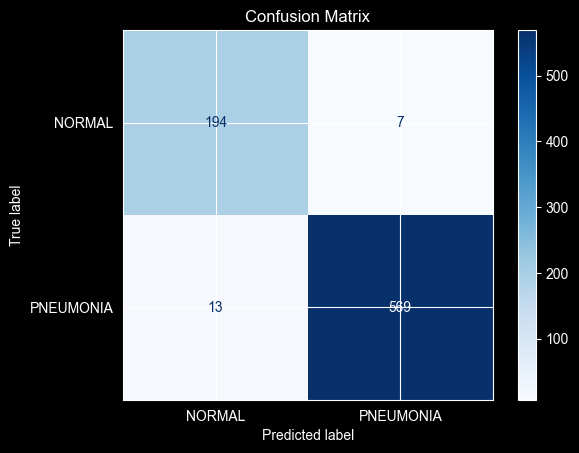

In [9]:
evaluate(model=model,
         threshold=THRESHOLD,
         data_loader=test_loader,
         device=device,
         labels=["NORMAL", "PNEUMONIA"])